In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
######### ieee smaller plot
import matplotlib as mpl
mpl.rcParams.update({
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

plt.rcParams['lines.markersize'] = 7

In [3]:
igibson_data = {}
for key in ['noise', 'bias']:
    file = 'igibson_{}.json'.format(key) 
    with open(file) as json_data:
        igibson_data[key] = np.array(json.load(json_data))

igibson_zero = igibson_data['bias'][:, :, 3, :]
igibson_data['bias'] = np.delete(igibson_data['bias'], 3, axis=2)

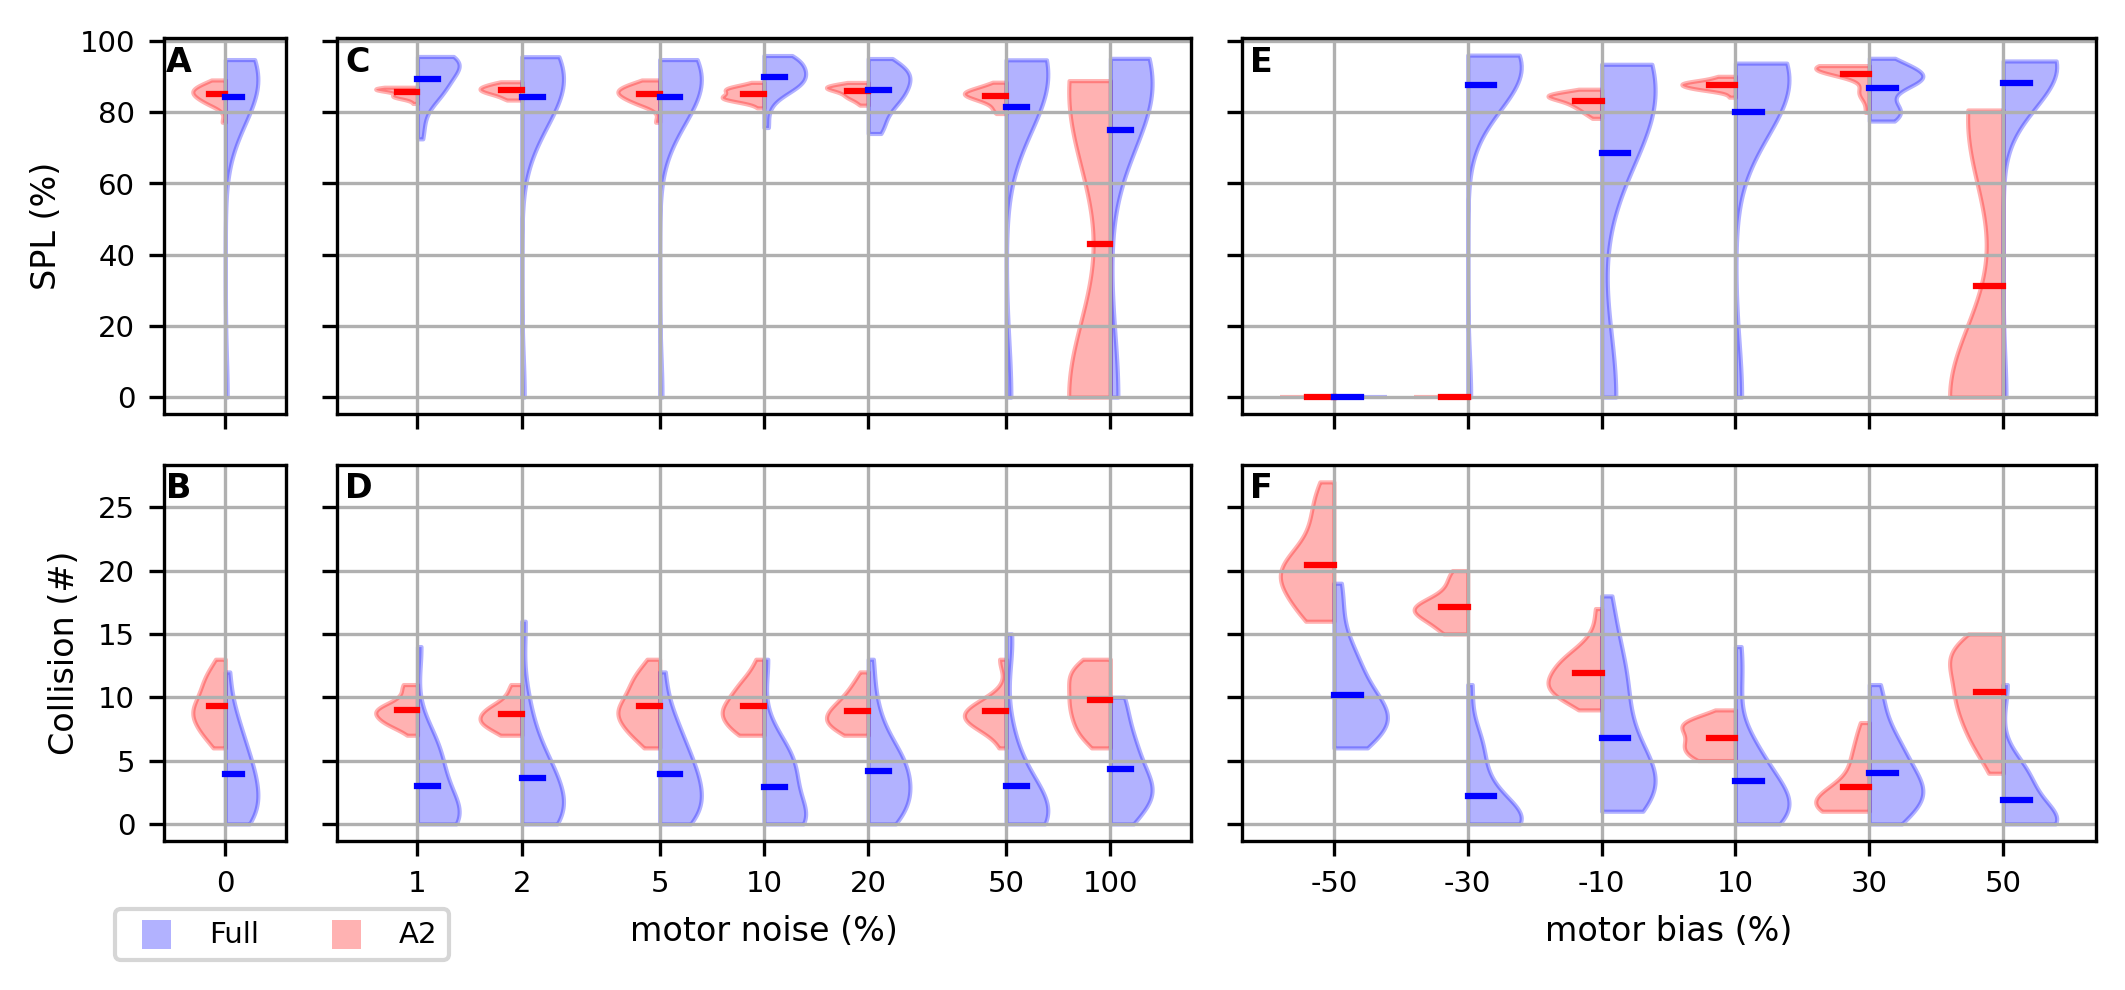

In [32]:
gs_kw = dict(width_ratios=[1, 7, 7], height_ratios=[1, 1])
fig, axes = plt.subplots(2, 3, figsize=(7.125, 3.3), gridspec_kw=gs_kw, dpi=300, layout='tight', sharex='col', sharey='row')

noise_x = np.array([1,2,5,10,20,50,100])
bias_x = np.array([-50, -30, -10, 10, 30, 50])

for axcol, (key, data_col_spl), xraw in zip(axes.T[1:], igibson_data.items(), [noise_x, bias_x]):
    if key == 'noise':
        xx = np.log(xraw) 
    else:
        xx = xraw
    for ax, dat in zip(np.flip(axcol), data_col_spl):
        for dc, c, half in zip(dat, 'rb', ['low', 'high']):
            parts=ax.violinplot(dc.T, 
                                positions=xx,                                       
                                widths=(xx[1]-xx[0])*.8,
                                side = half,
                                showextrema=False, 
                                showmeans=True
                             )
            for pc in parts['bodies']:
                pc.set_facecolor(c)
                pc.set_edgecolor(c)
                pc.set_alpha(0.3)      
            parts['cmeans'].set_edgecolor(c)
    
        ax.set_xticks(xx, xraw)

for ax, key in zip(axes[1, 1:], ('noise', 'bias')):
    ax.set_xlabel(f'motor {key} (%)')


for ax, dat, yl in zip(np.flip(axes.T[0]), igibson_zero, ('Collision (#)', 'SPL (%)')):
    for dc, c, half in zip(dat, 'rb', ['low', 'high']):
        parts=ax.violinplot(dc.T, 
                            positions=[0], 
                            widths=(xx[1]-xx[0])*.8,
                            side = half,
                            showextrema=False, 
                            showmeans=True
                         )
        for pc in parts['bodies']:
            pc.set_facecolor(c)
            pc.set_edgecolor(c)
            pc.set_alpha(0.3) 
        parts['cmeans'].set_edgecolor(c)
    
    ax.set_xticks([0])
    ax.set_xlim(-15, 15)
    ax.set_ylabel(yl)

ax.scatter([], [], marker='s', alpha=0.3, edgecolor='none', facecolor='b', label='Full')
ax.scatter([], [], marker='s', alpha=0.3, edgecolor='none', facecolor='r', label='A2')
fig.legend(bbox_to_anchor=[0.05, 0.05], loc='center left', ncol=4)

for ax, label in zip(axes.flatten(), 'ACEBDF'):
    ax.grid()
    ax.text(
        0.01, 0.98, label,
        transform=ax.transAxes,   # axes coordinates (0–1)
        fontsize=8,
        fontweight='bold',
        va='top',                 # anchor text to top
        ha='left'
    )
    
plt.savefig("igibson-summary.pdf", format="pdf", bbox_inches="tight", dpi=600)